# **Podcast Data Analysis Project**


## Project Description


In this project, a dataset of podcast episodes is analyzed to explore the data using statistical summaries and visualizations, and to examine which variables may influence listening time (`Watch_Time_minutes`).
<br>
<br>
The analysis includes the following steps:

1. General statistics of the dataset
2. Counting categorical and numerical variables
3. Description of categorical variables
4. Description of numerical variables
5. Detection of missing values
6. Handling missing values
7. Detection and Handling of Outliers
8. Normalization of numerical variables
9. Correlation analysis between variables
10. Visualization of variable distributions
11. Visualization of variables with the target variable (Watch_Time_minutes)

---

 ## Environment Setup and Data Loading

This section imports the required libraries and loads the dataset.  


In [ ]:

# The code is executed in Google Colab where the required libraries are already installed
# If needed, they can be installed using pip (e.g., pip install seaborn).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tool for normalization (standardization)
from sklearn.preprocessing import StandardScaler

# Display all columns when printing the dataset
pd.set_option('display.max_columns', None)

# Set visualization style for plots
sns.set_theme(style="whitegrid")

# load dataset
!wget -q https://github.com/noakohn/Podcast-Data-Analysis-Project/raw/main/train-2.zip
!unzip -oq train-2.zip
df = pd.read_csv("train-2.csv")

df.head()

,id,Name,Event_Number,Event_Length_minutes,Genre,Host_Popularity_percentage,Event_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Sponsers,Event_Sentiment,Watch_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


##1. General Statistics of the Dataset

In this section I present general information about the dataset.

I examine:
- the number of observations
- the number of variables
- the column names
- the data types of each variable

This step helps us understand the overall structure of the dataset and provides an initial overview of the data before further analysis.

In [ ]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

print("\nColumn names:")
print(df.columns)

# Display data types of each variable
print("\nData types:")
print(df.dtypes)



Number of observations: 750000
Number of variables: 12

Column names:
Index(['id', 'Name', 'Event_Number', 'Event_Length_minutes', 'Genre',
       'Host_Popularity_percentage', 'Event_Day', 'Publication_Time',
       'Guest_Popularity_percentage', 'Number_of_Sponsers', 'Event_Sentiment',
       'Watch_Time_minutes'],
      dtype='object')

Data types:
id                               int64
Name                            object
Event_Number                    object
Event_Length_minutes           float64
Genre                           object
Host_Popularity_percentage     float64
Event_Day                       object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Sponsers             float64
Event_Sentiment                 object
Watch_Time_minutes             float64
dtype: object


---

**Key Observations**

From the output above, I can see that the dataset contains 750,000 observations and 12 variables.


The dataset includes both numerical variables (such as id, event length, host and guest popularity percentages, number of sponsors, and watch time) and categorical or textual variables (such as name, event number, genre, event day, publication time, and event sentiment).

---

## 2. Counting Categorical and Numerical Variables

In this section I identify which variables are categorical and which are numerical, and count how many variables belong to each type.


This distinction is important because different types of variables require different analysis methods and visualizations.


In [ ]:
# Identification and counting of categorical and numerical variables

numerical_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(exclude=[np.number]).columns


print("Numerical variables:")
print(numerical_columns)
print("Number of numerical variables:", len(numerical_columns))

print("\nCategorical variables:")
print(categorical_columns)
print("Number of categorical variables:", len(categorical_columns))

Numerical variables:
Index(['id', 'Event_Length_minutes', 'Host_Popularity_percentage',
       'Guest_Popularity_percentage', 'Number_of_Sponsers',
       'Watch_Time_minutes'],
      dtype='object')
Number of numerical variables: 6

Categorical variables:
Index(['Name', 'Event_Number', 'Genre', 'Event_Day', 'Publication_Time',
       'Event_Sentiment'],
      dtype='object')
Number of categorical variables: 6


---

**Key Observations**

From the output above, I can see that the dataset contains an equal number of numerical and categorical variables (6 each).


This indicates that the dataset includes both quantitative information and categorical variables, which may require different analysis and visualization methods.

---

## 3. Description of Categorical Variables

In this section I examine the categorical variables.

For each categorical variable I analyze:
- the number of different categories (unique values)
- the frequency of each category


In [ ]:
# Loop through each categorical variable and display its different values and their frequencies
for col in categorical_columns:

    print("Variable:", col)
    print("Number of different values:", df[col].nunique())

    display(df[col].value_counts().reset_index())

Variable: Name
Number of different values: 48


,Name,count
0,Tech Talks,22847
1,Sports Weekly,20053
2,Funny Folks,19635
3,Tech Trends,19549
4,Fitness First,19488
5,Business Insights,19480
6,Style Guide,19364
7,Game Day,19272
8,Melody Mix,18889
9,Criminal Minds,17735


Variable: Event_Number
Number of different values: 100


,Event_Number,count
0,Episode 71,10515
1,Episode 62,10373
2,Episode 31,10292
3,Episode 61,9991
4,Episode 69,9864
...,...,...
95,Episode 2,5134
96,Episode 25,5117
97,Episode 41,4965
98,Episode 37,4940


Variable: Genre
Number of different values: 10


...

,Event_Day,count
0,Sunday,115946
1,Monday,111963
2,Friday,108237
3,Wednesday,107886
4,Thursday,104360
5,Saturday,103505
6,Tuesday,98103


Variable: Publication_Time
Number of different values: 4


,Publication_Time,count
0,Night,196849
1,Evening,195778
2,Afternoon,179460
3,Morning,177913


Variable: Event_Sentiment
Number of different values: 3


,Event_Sentiment,count
0,Neutral,251291
1,Negative,250116
2,Positive,248593


---

**Key Observations**

From the output above, I can see that the categorical variables contain different numbers of categories and values with different frequencies.
<br>

For example, **the variable Genre** includes 10 different podcast categories, where Sports, Technology, and True Crime appear most frequently, while Education appears less frequently compared to the other categories.  

**The variable Event_Day** includes 7 categories representing the days of the week, where Sunday has the highest count and Tuesday the lowest count.  

**Publication_Time** includes 4 categories, where Night and Evening appear more frequently compared to Morning and Afternoon.  

**Event_Sentiment** includes 3 categories, and the counts between them are relatively similar.

In addition, the variables **Name** and **Event_Number** are expected to contain a very large number of unique values, since they represent different names and different event numbers rather than a small set of repeated categories.
<br>
<br>
Overall, I can see that the categories appear with different frequencies, which may influence the data analysis in the next stages.

---

## 4. Description of Numerical Variables

In this section I analyze the numerical variables using summary statistics.

These statistics include: count, mean, standard deviation, minimum and maximum, quartiles



In [ ]:
# Show summary statistics of numerical variables
numerical_columns_no_id = numerical_columns.drop("id")
df[numerical_columns_no_id].describe()

,Event_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Sponsers,Watch_Time_minutes
count,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,64.504738,59.859901,52.236449,1.348855,45.437406
std,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,1.300000,0.000000,0.000000,0.000000
25%,35.730000,39.410000,28.380000,0.000000,23.178350
50%,63.840000,60.050000,53.580000,1.000000,43.379460
75%,94.070000,79.530000,76.600000,2.000000,64.811580
max,325.240000,119.460000,119.910000,103.910000,119.970000


---

 **Key Observations**

The average podcast listening time (Watch_Time_minutes) is approximately 45 minutes, with values ranging from 0 to about 120 minutes.

In addition, it can be observed from the summary statistics table that in several variables the number of observations is smaller than 750,000, indicating the presence of missing values in the dataset.

---

## 5. Detection of missing values

In this step I identify which variables contain missing values and count the number of missing values in each variable.

In [ ]:
print("Number of missing values:")
missing_values = df.isnull().sum()

missing_values

Number of missing values:


,0
id,0
Name,0
Event_Number,0
Event_Length_minutes,87093
Genre,0
Host_Popularity_percentage,0
Event_Day,0
Publication_Time,0
Guest_Popularity_percentage,146030
Number_of_Sponsers,1


---

**Key Observations**

From the output above, I can see that missing values appear only in a small number of variables.  
In particular, the variable Event_Length_minutes contains 87,093 missing values and Guest_Popularity_percentage contains 146,030 missing values. In addition, the variable Number_of_Sponsors contains only one missing value.

These missing values will be taken into account in the following stages of the analysis.

---

## 6. Handling Missing Values

In this step I handle missing values in the dataset.


Missing values are handled as follows:

- numerical variables are filled using the median
- categorical variables are filled using the most frequent value (mode)

In [ ]:
# Create a copy of the dataset so I can clean and modify the data without changing the original dataset.
#  This allows us to keep the raw data unchanged
# From this point on, I will work with the cleaned datase for the rest of the analysis in the project.
df_clean = df.copy()

# Loop through all variables in the dataset
for col in df_clean.columns:

    # Check if the variable contains missing values
    if df_clean[col].isnull().sum() > 0:

        # For numerical variables fill missing values with the median
        if df_clean[col].dtype in ["int64","float64"]:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

        # For categorical variables fill missing values with the most frequent value
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Check that missing values were handled
print("Number of missing values after handling:")
df_clean.isnull().sum()

Number of missing values after handling:


,0
id,0
Name,0
Event_Number,0
Event_Length_minutes,0
Genre,0
Host_Popularity_percentage,0
Event_Day,0
Publication_Time,0
Guest_Popularity_percentage,0
Number_of_Sponsers,0


---

**Key Observations**

From the output above, I can see that all missing values in the dataset have been successfully handled.


After filling the missing values, all variables now contain zero missing values.

This indicates that the dataset is now complete and ready for the next stages of the analysis.

---

## 7. Detection and Handling of Outliers

For each numerical variable I calculate the first quartile (the 25th percentile) and the third quartile (the 75th percentile).


Based on these values, lower and upper bounds are defined to identify extreme values.
Observations that fall outside these bounds are considered outliers.

To reduce their impact on the analysis, these values are replaced with the median value of the same variable.

In [ ]:
# Remove the "id" variable from the numerical variables list
# since it is only an identifier and does not provide meaningful information for outlier detection or the following analysis steps
numerical_columns = [col for col in numerical_columns if col != "id"]

# Create a list to store the number of outliers for each variable
outliers_summary = []

# Loop through all numerical variables
for col in numerical_columns:

    # Calculate quartiles using percentiles
    Q1 = np.percentile(df_clean[col], 25)
    Q3 = np.percentile(df_clean[col], 75)

    # Compute the quartile range
    quartile_range = Q3 - Q1

    # Define bounds for outliers
    lower = Q1 - 1.5 * quartile_range
    upper = Q3 + 1.5 * quartile_range

    # Identify outliers
    outliers_mask = (df_clean[col] < lower) | (df_clean[col] > upper)

    # Count outliers
    outliers = outliers_mask.sum()

    # Save results
    outliers_summary.append([col, outliers])

    # Replace outliers with the median value
    median_value = df_clean[col].median()
    df_clean.loc[outliers_mask, col] = median_value

# Convert results into a DataFrame
print("Number of outliers detected in each numerical variable before treatment:")
display(pd.DataFrame(outliers_summary, columns=["Variable", "Number of Outliers"]))

# empty line for spacing
print()
print()
print()

# Check outliers again after replacement
outliers_after = []

for col in numerical_columns:

    Q1 = np.percentile(df_clean[col], 25)
    Q3 = np.percentile(df_clean[col], 75)

    quartile_range = Q3 - Q1

    lower = Q1 - 1.5 * quartile_range
    upper = Q3 + 1.5 * quartile_range

    outliers_mask = (df_clean[col] < lower) | (df_clean[col] > upper)

    outliers = outliers_mask.sum()

    outliers_after.append([col, outliers])

# Display the number of outliers after treatment
print("Number of outliers remaining after treatment:")
display(pd.DataFrame(outliers_after, columns=["Variable", "Number of Outliers After Treatment"]))

Number of outliers detected in each numerical variable before treatment:


,Variable,Number of Outliers
0,Event_Length_minutes,1
1,Host_Popularity_percentage,0
2,Guest_Popularity_percentage,0
3,Number_of_Sponsers,9
4,Watch_Time_minutes,0





Number of outliers remaining after treatment:


,Variable,Number of Outliers After Treatment
0,Event_Length_minutes,0
1,Host_Popularity_percentage,0
2,Guest_Popularity_percentage,0
3,Number_of_Sponsers,0
4,Watch_Time_minutes,0


---

**Key Observations**

From the output above, I can see that there are outliers only in a small number of numerical variables.

 Before the treatment, 1 outlier appears in Event_Length_minutes and 9 outliers appear in Number_of_Sponsors, while the other numerical variables do not contain outliers.

After replacing the outliers with the median value, no outliers remain in any of the numerical variables. This indicates that the outlier treatment was successful and that the dataset is now more suitable for the next stages of the analysis.

---

## 8. Normalization of Numerical Variables

Numerical variables may be measured on different scales.

To make them comparable I normalize them using standardization.

In [ ]:
# Create a scaler to standardize the data
scaler = StandardScaler()

# Select numerical columns to scale (excluding 'Watch_Time_minutes')
# 'Watch_Time_minutes' is kept in its original scale for easier interpretation,
# while other variables are standardized for comparison in later steps.
cols_to_scale = [col for col in numerical_columns if col != "Watch_Time_minutes"]

# Display the mean and standard deviation before normalization
print("Before normalization:")
before_norm = pd.DataFrame({
    'Mean': df_clean[cols_to_scale].mean(),
    'Standard Deviation': df_clean[cols_to_scale].std()
})
display(before_norm)  # Display the dataframe as a table

# Apply standardization
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

# Display the mean and standard deviation after normalization
print("\nAfter normalization:")
after_norm = pd.DataFrame({
    'Mean': df_clean[cols_to_scale].mean(),
    'Standard Deviation': df_clean[cols_to_scale].std()
})
display(after_norm)  # Display the dataframe as a table

# Explanation for the final table
print("\nExplanation: The table below shows the first rows of the dataset after normalization:")

# Display the first rows of the normalized dataset
display(df_clean.head())  # Display the first rows of the normalized dataset as a table

Before normalization:


,Mean,Standard Deviation
Event_Length_minutes,64.427198,30.995533
Host_Popularity_percentage,59.859901,22.873098
Guest_Popularity_percentage,52.498047,25.537152
Number_of_Sponsers,1.347880,1.110961



After normalization:


,Mean,Standard Deviation
Event_Length_minutes,5.688700e-16,1.000001
Host_Popularity_percentage,-6.141552e-16,1.000001
Guest_Popularity_percentage,-9.439797e-17,1.000001
Number_of_Sponsers,7.205851e-17,1.000001



Explanation: The table below shows the first rows of the dataset after normalization:


,id,Name,Event_Number,Event_Length_minutes,Genre,Host_Popularity_percentage,Event_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Sponsers,Event_Sentiment,Watch_Time_minutes
0,0,Mystery Matters,Episode 98,-0.018945,True Crime,0.653611,Thursday,Night,0.042368,-1.213257,Positive,31.41998
1,1,Joke Junction,Episode 26,1.786478,Comedy,0.309976,Saturday,Afternoon,0.918347,0.586988,Negative,88.01241
2,2,Study Sessions,Episode 16,0.305619,Education,0.442009,Tuesday,Evening,-1.704500,-1.213257,Negative,44.92531
3,3,Digital Digest,Episode 45,0.088490,Technology,-0.115415,Monday,Morning,1.026033,0.586988,Positive,46.27824
4,4,Mind & Body,Episode 86,1.486757,Health,0.883576,Monday,Afternoon,0.242077,1.487110,Neutral,75.61031


---

**Key Observations**

From the output above, I can see that:
<br>
<br>
**Before normalization**: The table shows the mean and standard deviation of each numerical variable before any scaling was applied.

This helps us understand the distribution of the data before any adjustments.

Each variable can have a different mean and standard deviation, and this gives us an idea of how the data is spread out initially.
<br>
<br>

**After normalization**: The variables now have a mean of 0 and a standard deviation of 1, making them more comparable to each other.

This ensures that no variable dominates the others due to differences in scale.
<br>
<br>
In addition, the table with the normalized values has been included to show how the data has been transformed after standardization.

---

## 9. Correlation Analysis Between Variables

Correlation analysis helps us understand the relationships between numerical variables.

Special attention is given to the relationship between the variables and `Watch_Time_minutes`.

Correlation Matrix of Numerical Variables:


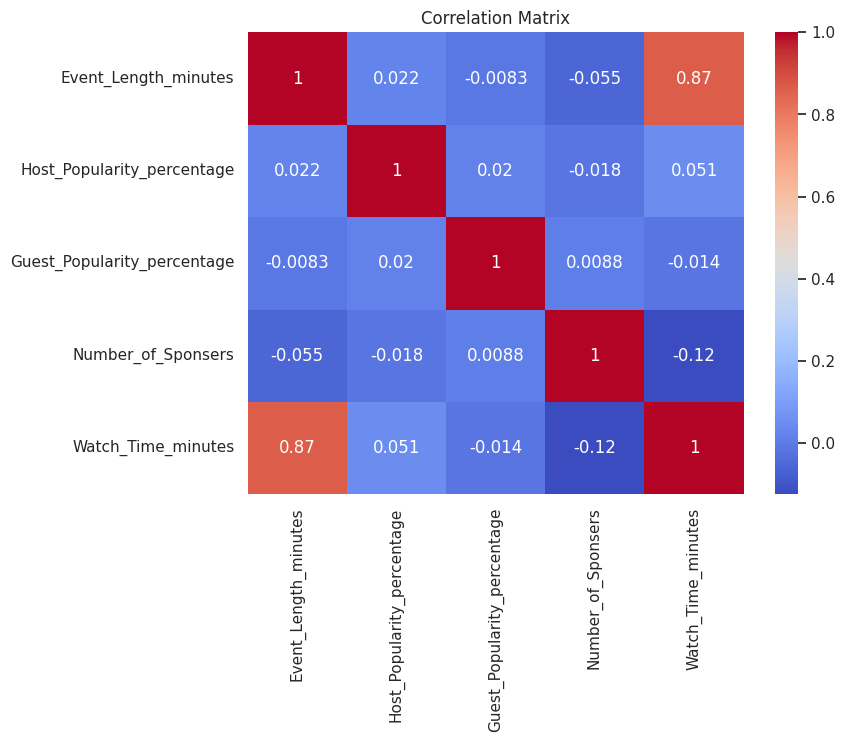


Now we display the correlations between the variables and the target variable (Watch_Time_minutes) only:


,Watch_Time_minutes
Watch_Time_minutes,1.000000
Event_Length_minutes,0.866254
Host_Popularity_percentage,0.050870
Guest_Popularity_percentage,-0.014446
Number_of_Sponsers,-0.124196


In [ ]:
# Compute correlation matrix for numerical variables
corr_matrix = df_clean[numerical_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

print("Correlation Matrix of Numerical Variables:")
plt.title("Correlation Matrix")
plt.show()

# empty line for spacing
print()

# explanation before showing correlations with the target variable
print("Now I display the correlations between the variables and the target variable (Watch_Time_minutes) only:")

# Display correlations with the target variable
corr_matrix["Watch_Time_minutes"].sort_values(ascending=False)

---

**Key Observations**

First, I performed a correlation analysis between the numerical variables in order to check whether relationships exist between the different variables. This step helps identify whether there are variables that are strongly related to each other, which could influence the later stages of the analysis.

From the overall correlation matrix, I can see that most of the correlations between the numerical variables are very weak and close to zero. In other words, there doesn't appear to be a strong relationship between most of the variables, and each variable behaves relatively independently from the others.

In addition, I separately displayed a table showing the correlation between each variable and the target variable `Watch_Time_minutes`. The values are sorted from the highest correlation to the lowest in order to make it easier to understand how strongly each variable is related to watch time.

From the output I can observe that:

1. `Event_Length_minutes` shows a strong positive correlation (0.87) with `Watch_Time_minutes`, meaning that longer events tend to be associated with higher watch time.

2. `Host_Popularity_percentage` shows a very weak positive correlation (0.05) with `Watch_Time_minutes`, indicating that the host's popularity has little effect on watch time.

3. `Guest_Popularity_percentage` shows a very weak negative correlation (-0.01) with `Watch_Time_minutes`, suggesting that the guest's popularity is almost unrelated to watch time.

4. `Number_of_Sponsors` shows a weak negative correlation (-0.12) with `Watch_Time_minutes`, meaning that events with more sponsors tend to be associated with slightly lower watch time.

Overall, I can see that `Event_Length_minutes` is the variable that shows the strongest relationship with `Watch_Time_minutes`, while the other variables show very weak relationships with watch time.
.


---

## 10. Visualization of Variable Distributions

In this section I visualize the distributions of the variables in the dataset, both individually and together.  
This understanding helps support the continuation of the analysis, as it allows us to understand the general behavior of the variables before examining the relationship between them and the target variable `Watch_Time_minutes`.



**Displaying the distribution of each numerical variable separately:**

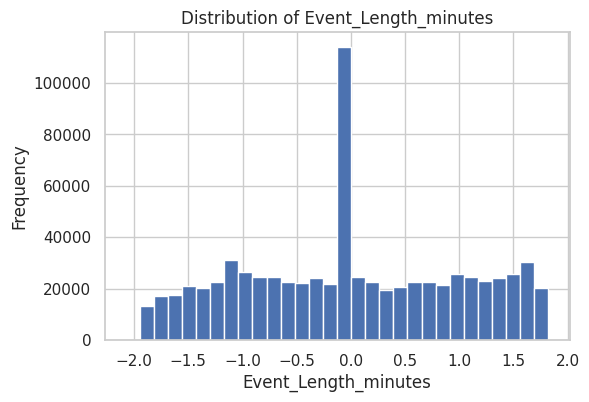

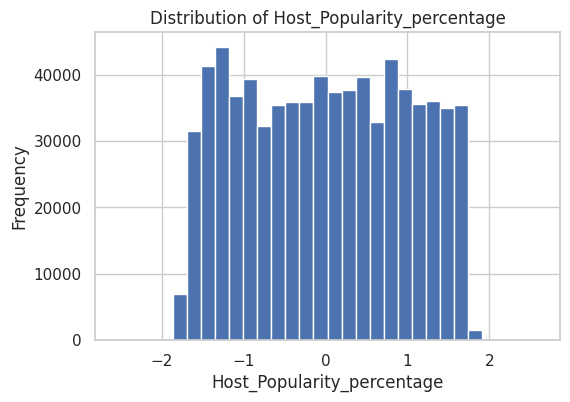

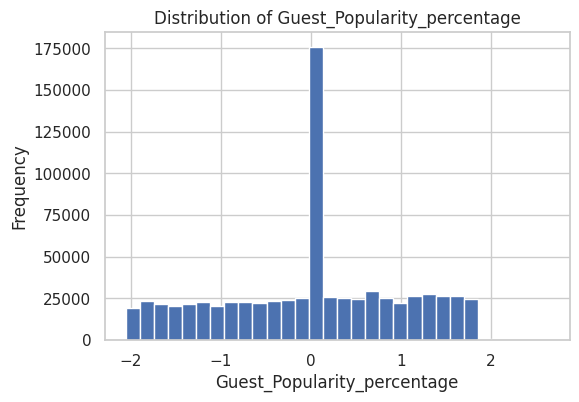

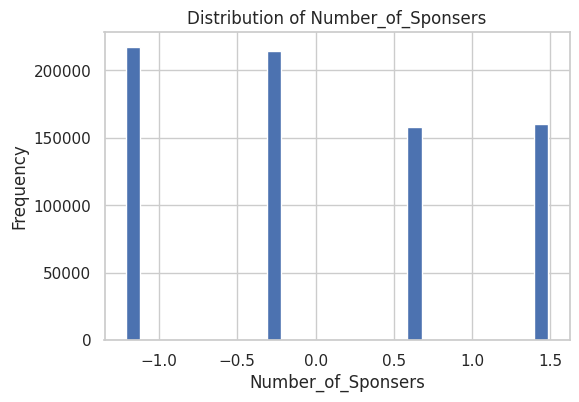

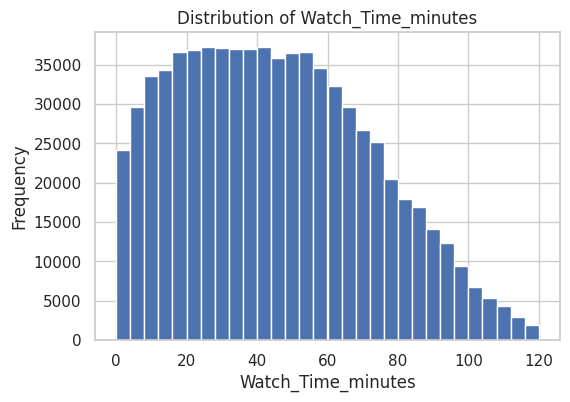

In [ ]:
# Plot distribution (histogram) for each numerical variable:
for col in numerical_columns:


        plt.figure(figsize=(6,4))

        plt.hist(df_clean[col], bins=30)

        plt.title("Distribution of " + col)

        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.show()

---

 **Key Observations**

From the histograms above, I can see how the numerical variables are distributed in the dataset.

The variables `Event_Length_minutes`, `Host_Popularity_percentage`, and `Guest_Popularity_percentage` appear to be concentrated roughly around zero. This is reasonable since these variables were standardized during the normalization step.
<br>
<br>
For the variable `Number_of_Sponsors`, I can see that only a small number of different values appear in the histogram. This suggests that the number of sponsors per episode is usually relatively small.
<br>
<br>
In the distribution of `Watch_Time_minutes`, I can see that most values are located in the first to middle part of the distribution, and the frequency gradually decreases as watch time increases.


---

**Displaying the distribution of each categorical variable separately:**

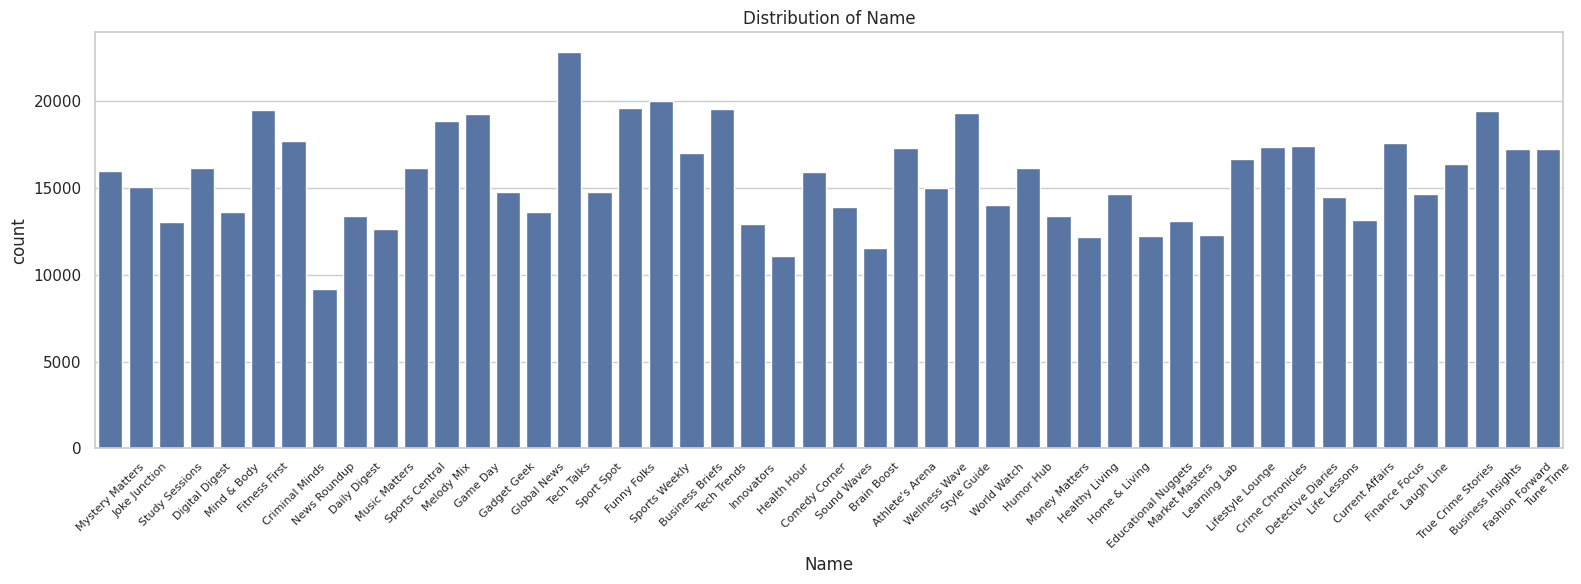

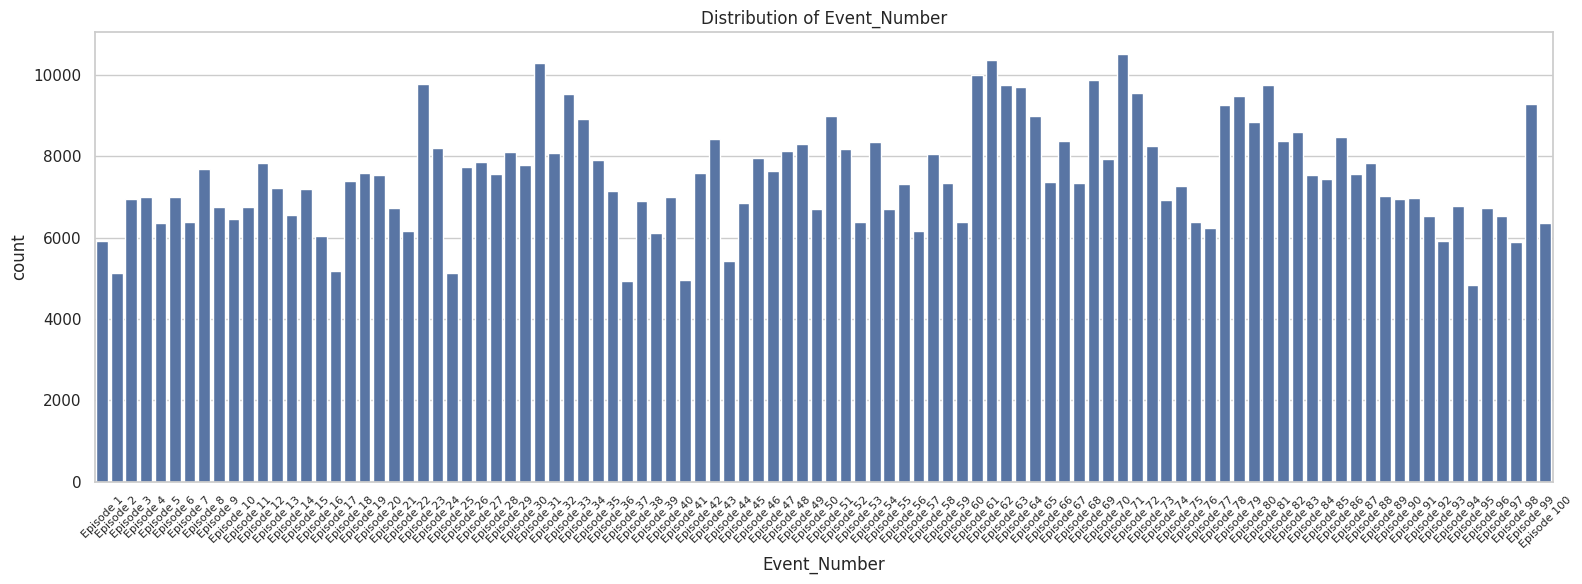

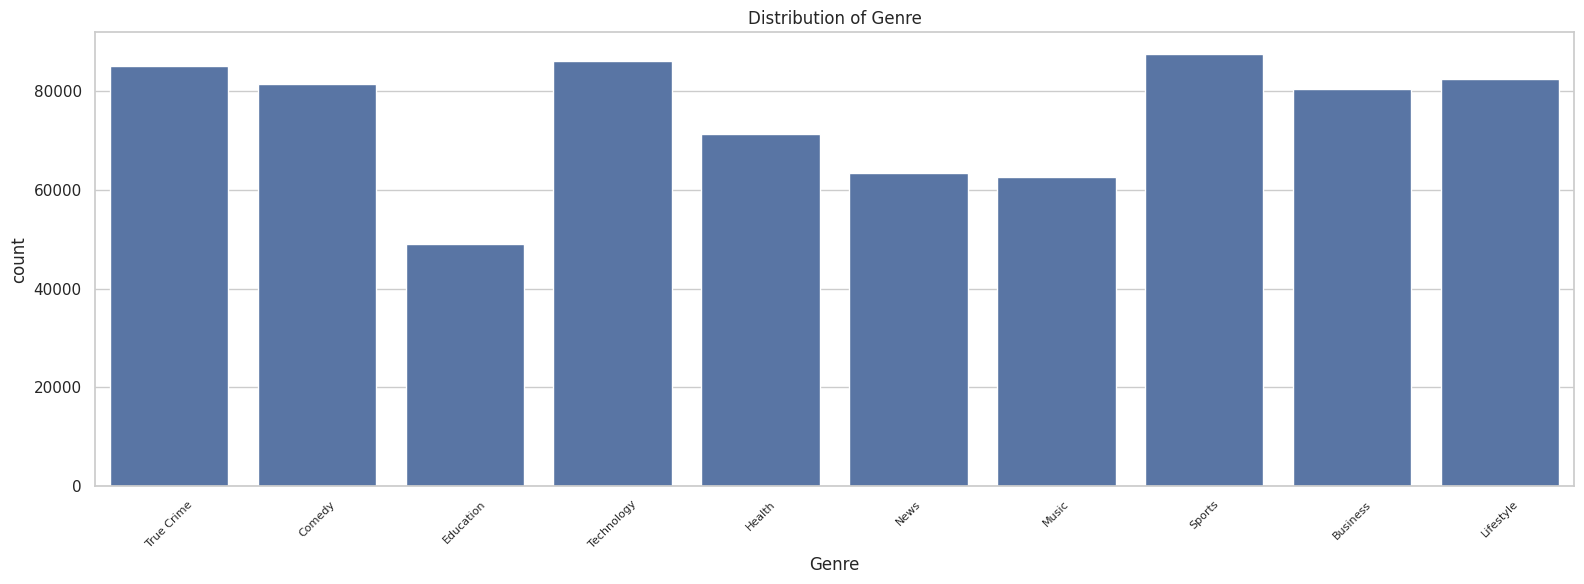

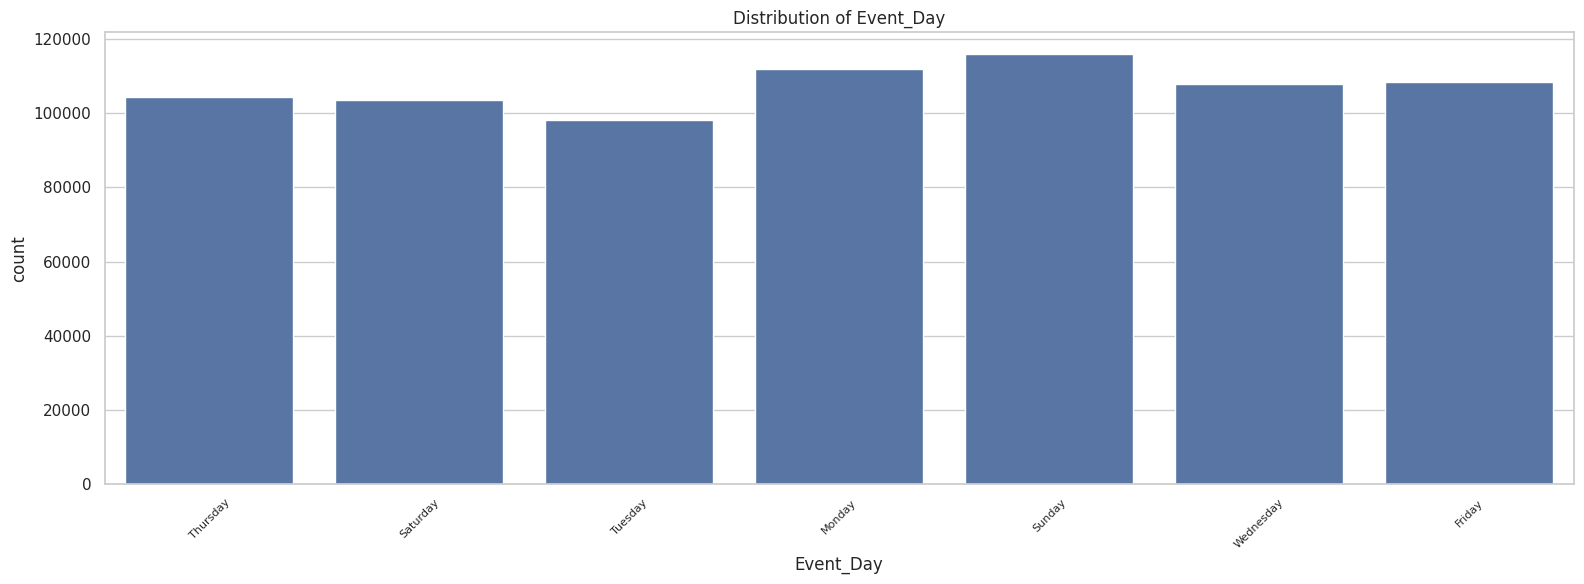

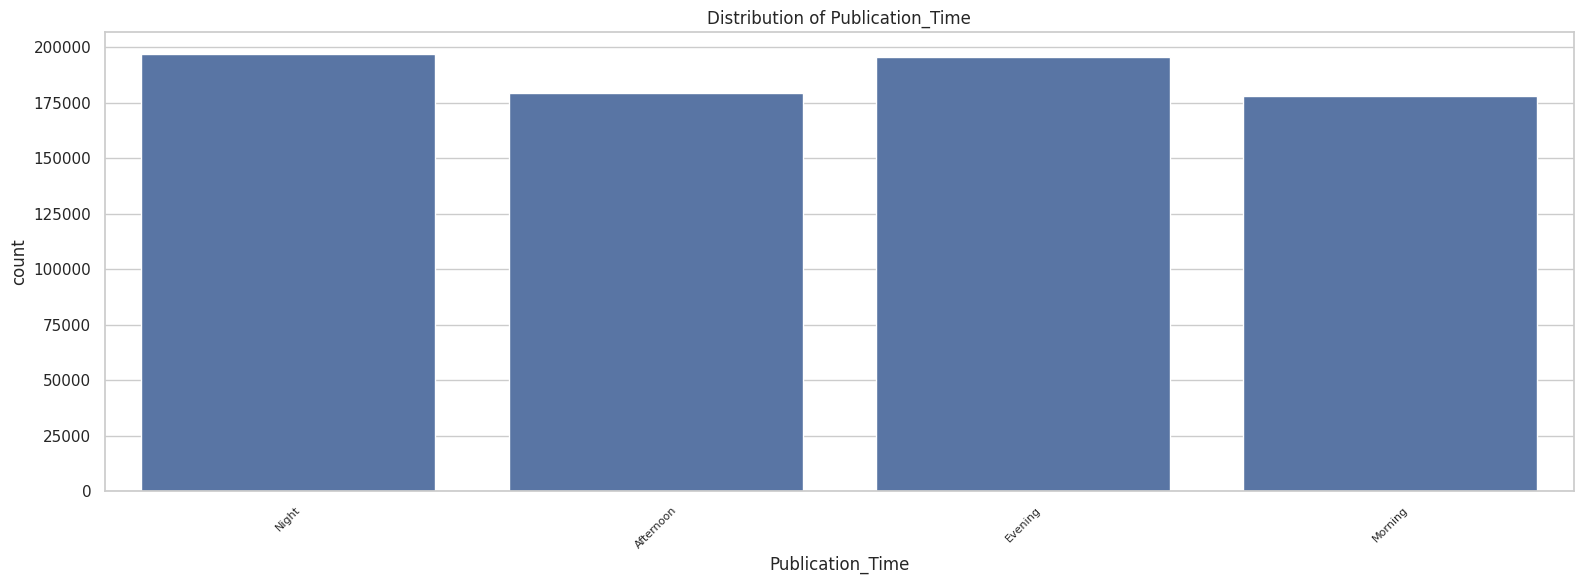

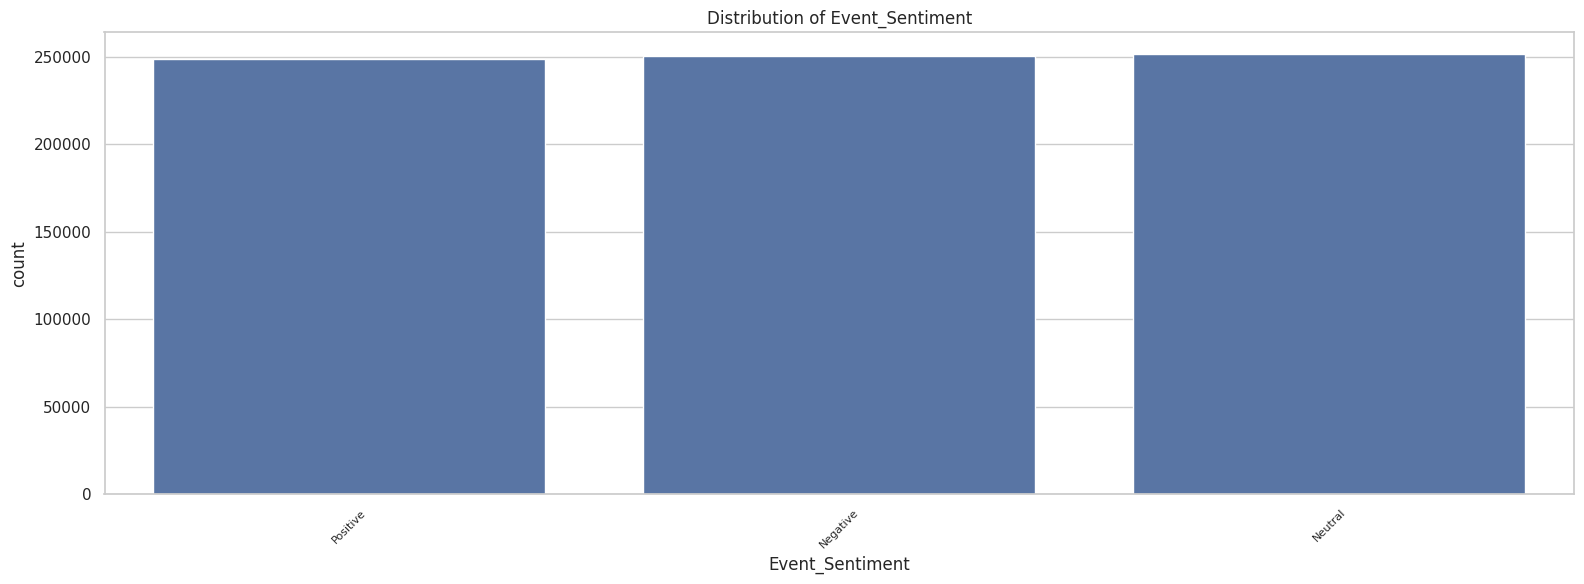

In [ ]:
# Plot distribution (count plot) for each categorical variable:
for col in categorical_columns:

    plt.figure(figsize=(16,6))

    if col == "Event_Number":
        order = sorted(df_clean[col].unique(), key=lambda x: int(x.split()[-1]))
        sns.countplot(data=df_clean, x=col, order=order)
    else:
        sns.countplot(data=df_clean, x=col)

    plt.title("Distribution of " + col)

    plt.xticks(rotation=45, fontsize=8)

    plt.tight_layout()

    plt.show()




---

 **Key Observations**

From the count plots above, I can observe how the categorical variables are distributed in the dataset.

Looking at the variable `Genre`, I can see that the distribution between genres is not uniform. Some genres, such as "Sports" and "Technology", appear more frequently, while other genres like "Education" appear less often. This means that although the dataset includes a variety of podcast genres, there are differences in how frequently each genre appears.
<br>
<br>
For the variable `Event_Day`, I can see that podcasts are published on all days of the week, but there are some differences in the number of podcasts between the days. It can be seen that Sunday appears slightly more than the other days, but overall the distribution between the days is still quite similar.
<br>
<br>
A similar pattern can also be seen in the variable `Publication_Time`. I can see that podcasts are published at all times of the day — morning, afternoon, evening, and night - but there are some differences between the time periods. It appears that publications during the evening and night occur slightly more often compared to the morning and afternoon, but overall the distribution between the times is still quite similar.
<br>
<br>
For the variable `Event_Sentiment`, I can see that the counts of positive, negative, and neutral sentiment are also quite close to each other. This means that the dataset includes a mix of different sentiment types and is not dominated by a single category.
<br>
<br>
The variable `Event_Number` represents the episode index of the podcast. From the plot I can see that the counts are spread across the episode numbers without a clear pattern of certain episodes appearing more than others. This is expected since this variable mainly indicates the order of the episodes rather than characteristics of the content itself.
<br>
<br>
Finally, the variable `Name` represents the podcast title. From the plot I can see that the counts are spread across many podcast names, with some differences between the names. For example, "Tech Talks" appears more frequently compared to some of the other names, while "News Roundup" appears less frequently compared to the others.



---

**Displaying the distributions of variables together:**

Instead of presenting all possible combinations between variables, a few selected combinations are shown in order to keep the analysis clear and readable.

 The selected combinations include relationships between numerical variables, between numerical and categorical variables, and between two categorical variables.

  This step helps provide an initial understanding of how the variables relate to each other before examining their connection to the target variable (`Watch_Time_minutes`).

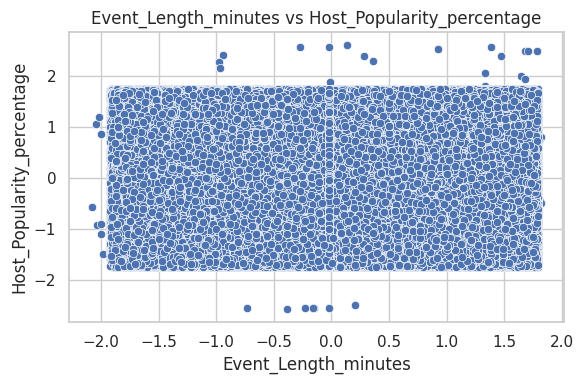

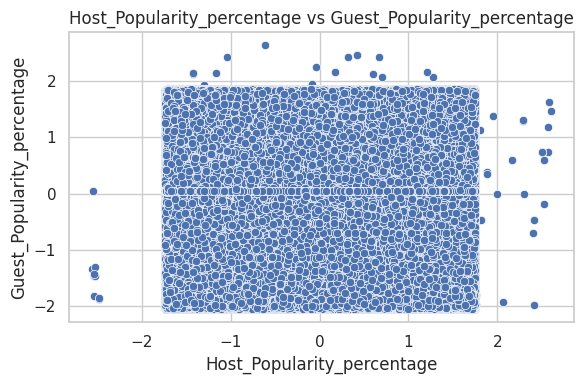

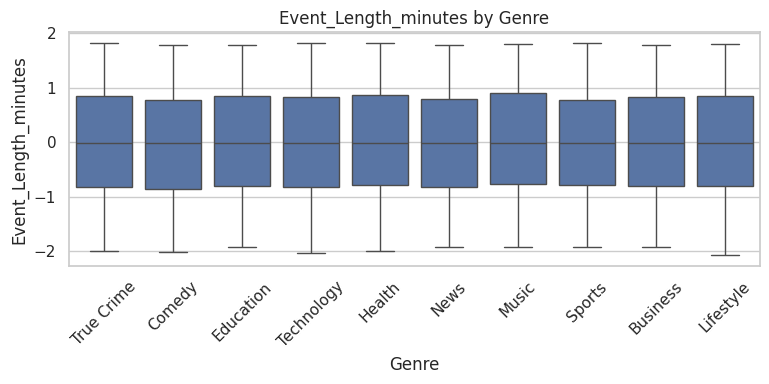

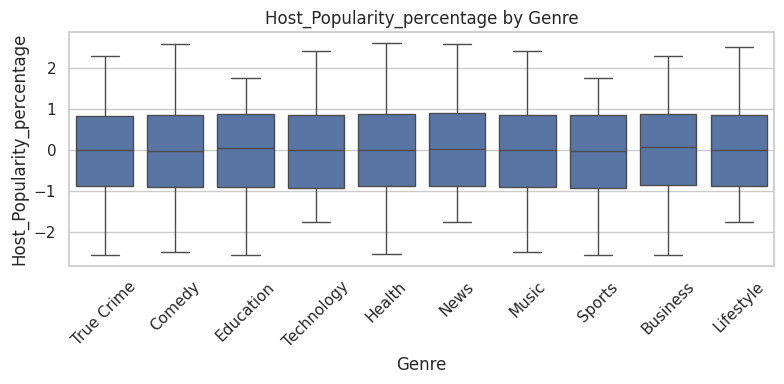

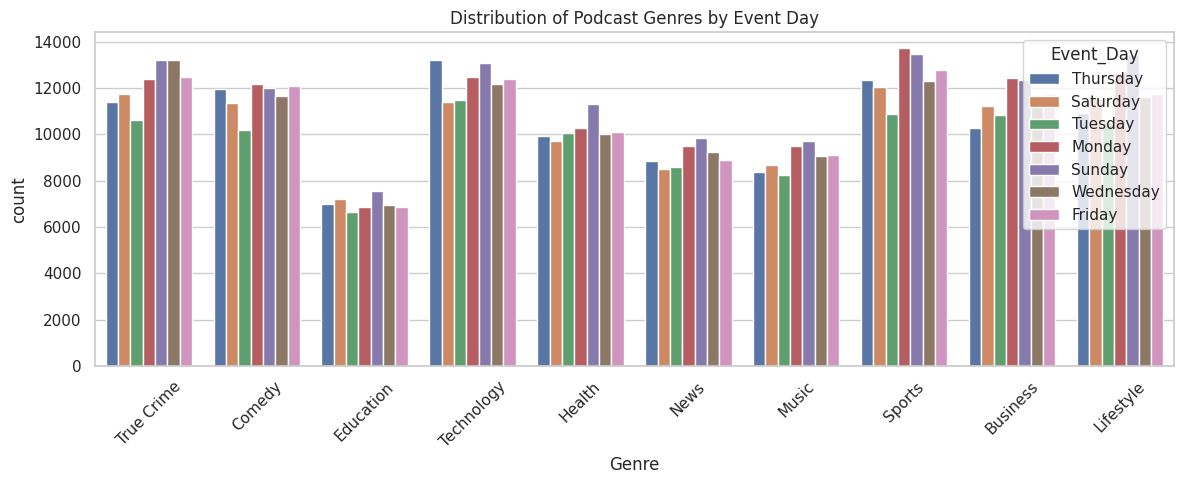

In [ ]:
# Visualization of relationships between variables (together)
# In this section I present several representative visualizations
# to explore potential relationships between variables in the dataset.



# ---------------------------------------------------------
# 1. Relationship between Event Length and Host Popularity
# Scatterplot helps examine whether longer events are associated
# with higher host popularity.
# ---------------------------------------------------------

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df_clean,
    x="Event_Length_minutes",
    y="Host_Popularity_percentage"
)

plt.title("Event_Length_minutes vs Host_Popularity_percentage")

plt.tight_layout()
plt.show()



# ---------------------------------------------------------
# 2. Relationship between Host Popularity and Guest Popularity
# This scatterplot explores whether more popular hosts tend to
# invite more popular guests.
# ---------------------------------------------------------

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df_clean,
    x="Host_Popularity_percentage",
    y="Guest_Popularity_percentage"
)

plt.title("Host_Popularity_percentage vs Guest_Popularity_percentage")

plt.tight_layout()
plt.show()



# ---------------------------------------------------------
# 3. Event Length by Genre
# Boxplot helps visualize how event length varies across
# different podcast genres.
# ---------------------------------------------------------

plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_clean,
    x="Genre",
    y="Event_Length_minutes"
)

plt.title("Event_Length_minutes by Genre")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



# ---------------------------------------------------------
# 4. Host Popularity by Genre
# This boxplot examines whether host popularity differs
# across podcast genres.
# ---------------------------------------------------------

plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_clean,
    x="Genre",
    y="Host_Popularity_percentage"
)

plt.title("Host_Popularity_percentage by Genre")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



# ---------------------------------------------------------
# 5. Distribution of Genre by Event Day
# Countplot helps examine how podcast genres are distributed
# across different days of the event.
# ---------------------------------------------------------

plt.figure(figsize=(12,5))

sns.countplot(
    data=df_clean,
    x="Genre",
    hue="Event_Day"
)

plt.title("Distribution of Podcast Genres by Event Day")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


---

 **Key Observations**

From the plots above, I can obtain an initial understanding of the relationships between some of the variables in the dataset.

The scatterplots show the relationship between `Event_Length_minutes` and `Host_Popularity_percentage`, as well as between `Host_Popularity_percentage` and `Guest_Popularity_percentage`.
<br>
 In both plots, the points appear widely spread without a clear pattern. This suggests that changes in one variable do not appear to be clearly associated with changes in the other.
<br>
<br>
In addition, boxplots were used to present the distributions of `Event_Length_minutes` and `Host_Popularity_percentage` across the different podcast genres (`Genre`).
<br>
 From these plots, it can be seen that the distributions across genres are relatively similar. Most genres show comparable ranges and medians, and no specific genre appears to have a dramatically different pattern.
 <br>
  In addition, no clear outlier points appear in the boxplots, which is consistent with what was done in Step 7 of the analysis, where extreme values in the data were examined and handled.
<br>
<br>
Finally, a plot combining `Genre` and `Event_Day` was presented in order to observe how podcast genres are distributed across different days of the week.
<br>
 From the plot, it can be seen that the distribution across genres is not identical throughout the week.
 <br>
  For example, `Education` appears less frequently on most days, while genres such as `Sports` and `Technology` appear more frequently. In addition, days such as `Monday` and `Sunday` tend to be slightly higher for some genres.


---

## 11. Visualization of variables with the target variable (Watch_Time_minutes)

In this section, I analyze the relationship between different variables and the watch time (`Watch_Time_minutes`).

These visualizations help identify which variables may influence podcast watch time.

**Displaying the relationship between each numerical variable and the target variable (`Watch_Time_minutes`):**

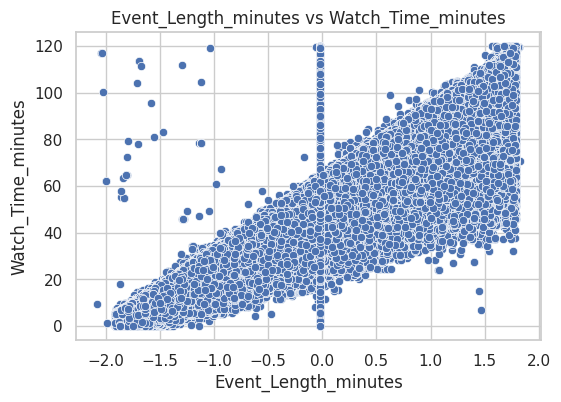

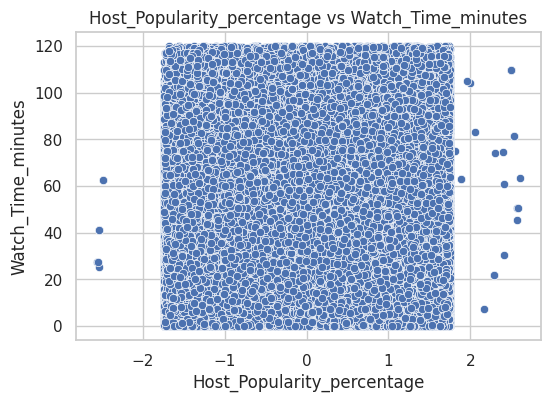

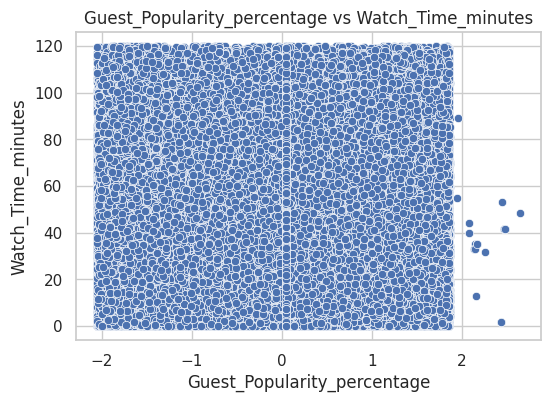

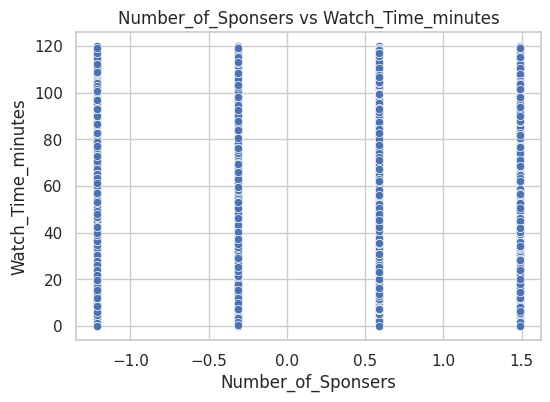

In [ ]:
# Plot scatterplots between numerical variables and the target variable (Watch_Time_minutes)

for col in numerical_columns:

    if col not in ["Watch_Time_minutes", "id"]:

        plt.figure(figsize=(6,4))

        sns.scatterplot(x=df_clean[col], y=df_clean["Watch_Time_minutes"])

        plt.title(col + " vs Watch_Time_minutes")

        plt.xlabel(col)
        plt.ylabel("Watch_Time_minutes")

        plt.show()

---

 **Key Observations**

From the plots above, I can obtain an understanding of the relationship between each of the numerical variables and the target variable `Watch_Time_minutes`.
<br>
<br>
The scatter plot of `Event_Length_minutes` vs. `Watch_Time_minutes` shows the clearest pattern among the variables presented. It appears that there is a positive relationship, meaning that higher values of `Event_Length_minutes` are generally associated with higher watch time. However, the points are still quite spread out, so the relationship doesn't appear to be very strong.
<br>
<br>
In addition, the scatter plots of `Host_Popularity_percentage` and `Guest_Popularity_percentage` vs. `Watch_Time_minutes` don't show a clear pattern. In both cases, the points are widely spread across the graph, making it difficult to identify a relationship between these variables and the watch time.
<br>
<br>
In the case of `Number_of_Sponsers`, the plot shows several vertical groups of points because this variable takes only a small number of possible values.
<br>
 Within each group, the watch time values are spread over a relatively wide range, and it doesn't appear that an increase in the number of sponsors is consistently associated with an increase or decrease in watch time. In other words, based on this plot, it is difficult to identify a clear relationship between the number of sponsors and `Watch_Time_minutes`.
<br>
<br>
Overall, it can be seen that `Event_Length_minutes` shows a slightly clearer pattern in relation to `Watch_Time_minutes`, while the variables `Host_Popularity_percentage`, `Guest_Popularity_percentage`, and `Number_of_Sponsers` don't show a clear relationship with the target variable.

---

**Displaying the relationship between each categorical variable and the target variable (`Watch_Time_minutes`):**

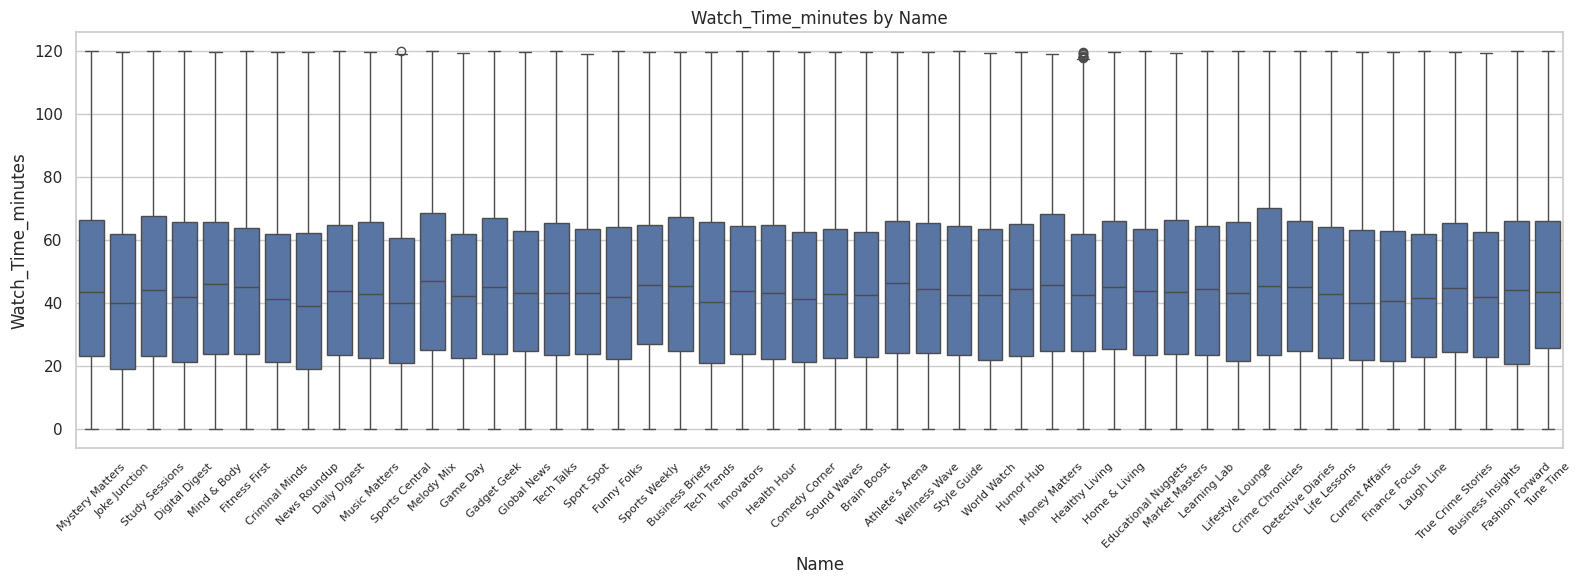

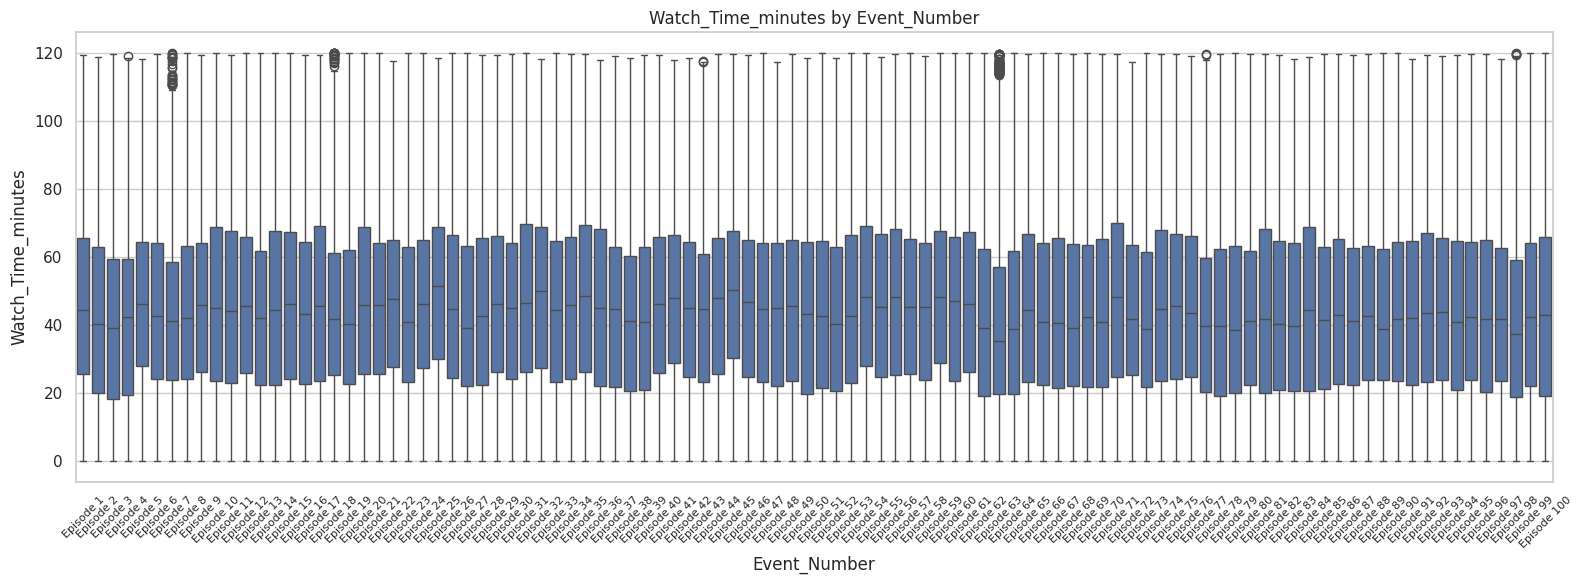

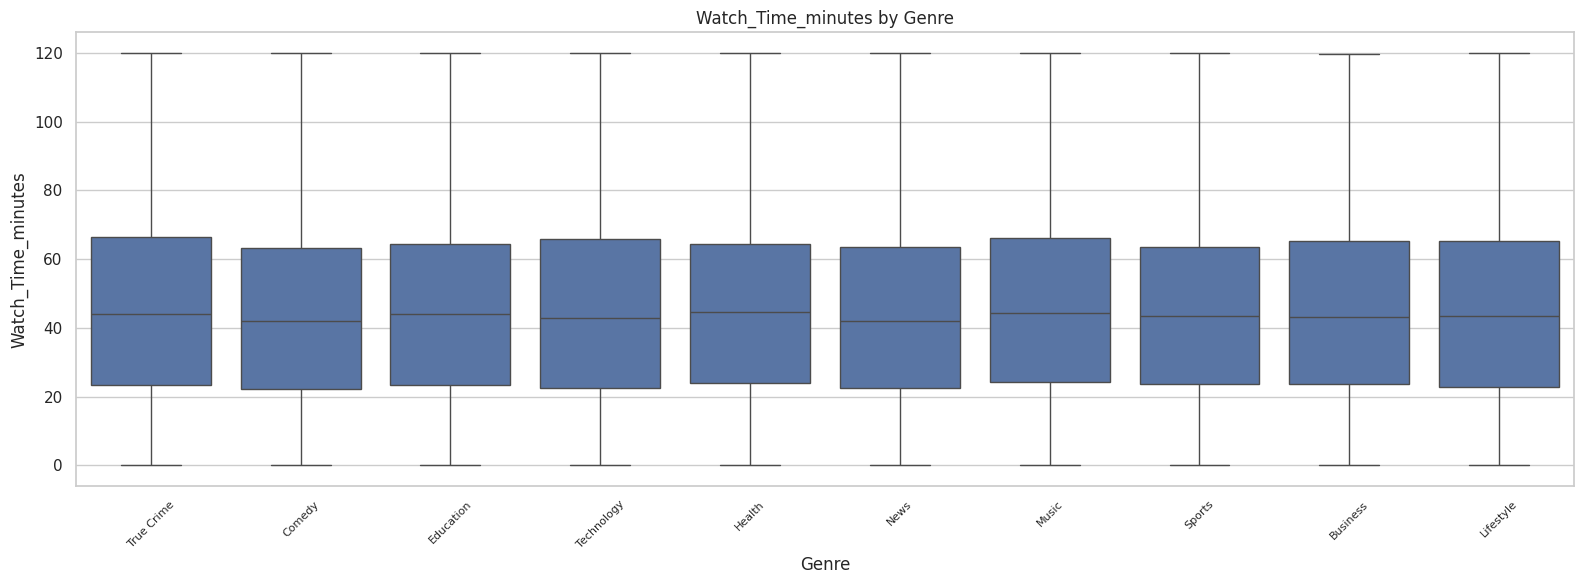

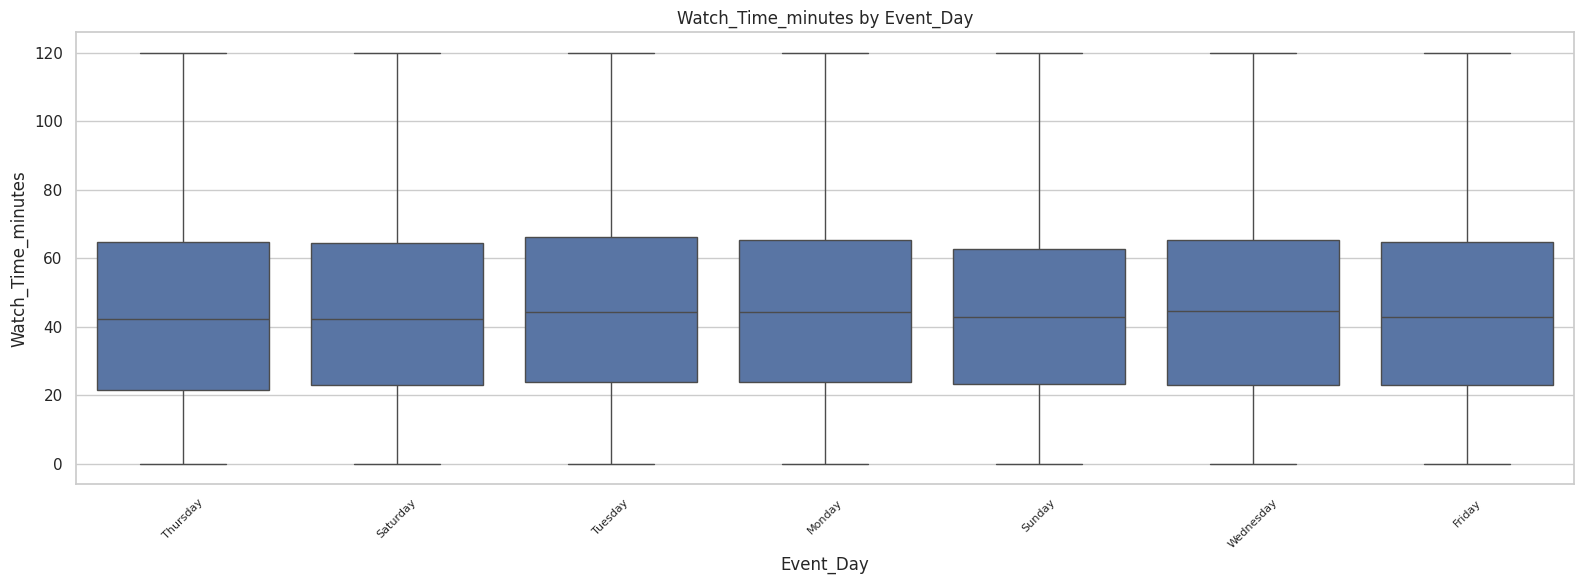

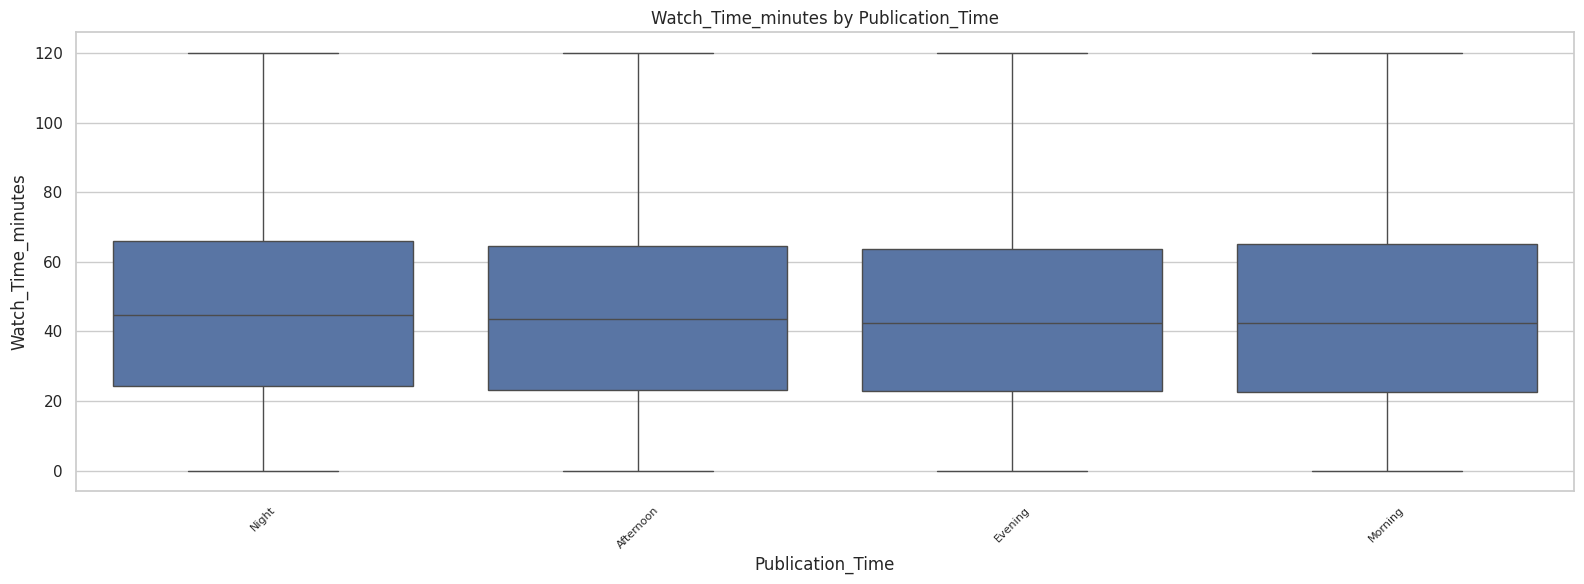

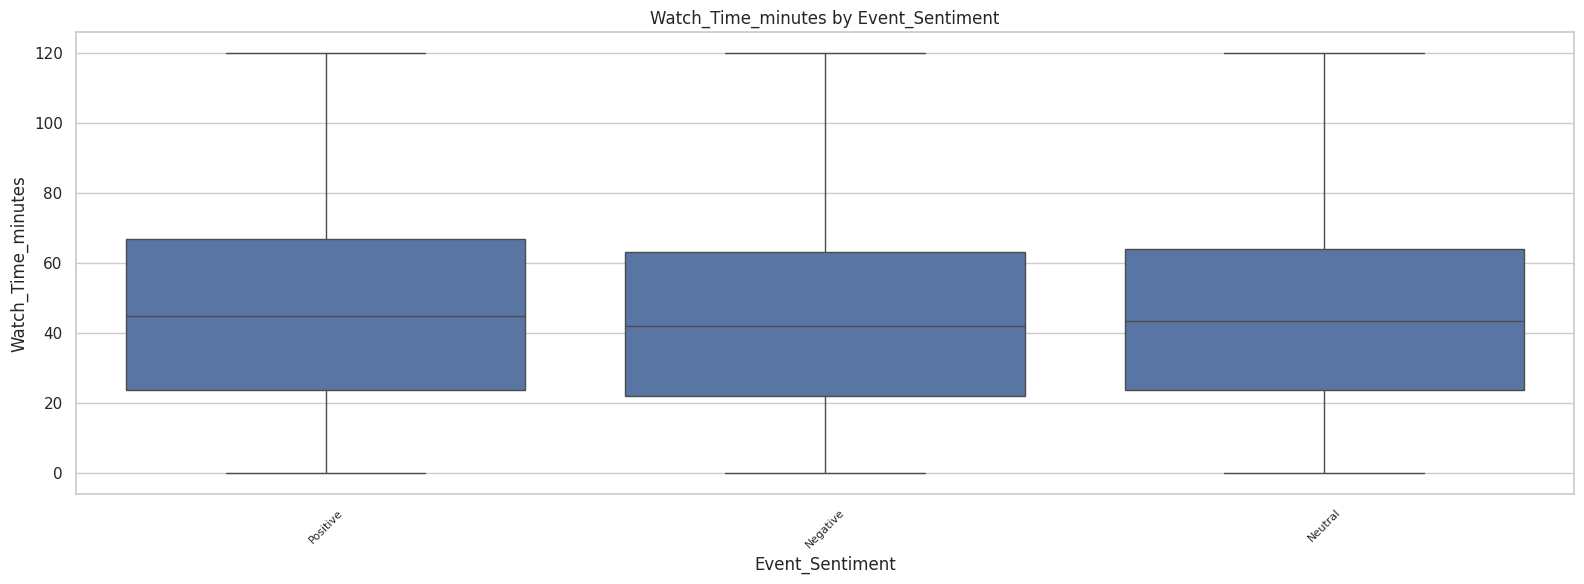

In [ ]:
# Plot boxplots between categorical variables and Watch_Time_minutes
for col in categorical_columns:

    plt.figure(figsize=(16,6))

    if col == "Event_Number":
        order = sorted(df_clean[col].unique(), key=lambda x: int(x.split()[-1]))
        sns.boxplot(data=df_clean, x=col, y="Watch_Time_minutes", order=order)
    else:
        sns.boxplot(data=df_clean, x=col, y="Watch_Time_minutes")

    plt.title("Watch_Time_minutes by " + col)

    plt.xticks(rotation=45, fontsize=8)

    plt.tight_layout()

    plt.show()


---

 **Key Observations**

From the plots above, I can obtain an understanding of the relationship between each categorical variable and the target variable `Watch_Time_minutes`.
<br>
<br>
The plot of `Watch_Time_minutes` by `Genre` shows that the distributions of watch time across the different genres are relatively similar.
 It can be seen that the boxes in the plot appear at similar heights across the genres, and therefore the watch time appears similar for most genres. In other words, there is no genre where the watch time is particularly higher or lower compared to the others. This may suggest that the genre of the podcast is not a major factor influencing the watch time.
<br>
<br>
The plot of `Watch_Time_minutes` by `Event_Day` also shows similar distributions across the days of the week. This suggests that the day on which the episode is published does not appear to significantly influence the watch time.
<br>
<br>
A similar pattern can also be observed in the plot of `Watch_Time_minutes` by `Publication_Time`. The distributions for "Morning", "Afternoon", "Evening", and "Night" appear relatively similar, suggesting that the publication time does not show a strong relationship with watch time.
<br>
<br>
In addition, the plot of `Watch_Time_minutes` by `Event_Sentiment` shows that the distributions for "Positive", "Neutral", and "Negative" are also quite similar. Therefore, the sentiment of the event does not appear to have a significant effect on watch time.
<br>
<br>
Finally, the plots for `Name` and `Event_Number` display a large number of categories. Nevertheless, it can be seen that in most categories the ranges of watch time appear relatively similar, and no specific category stands out with particularly high or low watch time compared to the others.
<br>
Therefore, these variables do not appear to strongly explain the watch time.
<br>
<br>
In summary, from the plots it can be seen that watch time (`Watch_Time_minutes`) is distributed in a similar way across the different categories in all the categorical variables that were examined. Therefore, based on these plots, these variables do not appear to show a strong relationship with watch time.

---

---

## **Final Conclusions**

In this project, I analyzed a dataset of podcast episodes in order to understand which factors may influence podcast listening time (`Watch_Time_minutes`).

The dataset contains 750,000 observations and includes both numerical and categorical variables describing podcast characteristics such as episode length, host and guest popularity, number of sponsors, genre, and publication time.
<br>
<br>
During the project, several steps were performed including checking the dataset, handling missing values, treating outliers, and normalizing the numerical variables, so that in the end a clean dataset suitable for analysis was obtained.
<br>
<br>
From the analyses and plots examined throughout the project, it can be seen that most variables do not show a strong relationship with the target variable `Watch_Time_minutes`.
<br>
 The variable that shows the clearest relationship with watch time is `Event_Length_minutes`, where longer episodes tend to be associated with higher watch time. In contrast, variables such as `Host_Popularity_percentage`, `Guest_Popularity_percentage`, and `Number_of_Sponsors` show a very weak relationship with watch time.
<br>
<br>
In addition, from the plots of the categorical variables it can be seen that watch time is distributed in a similar way across the different categories, and therefore variables such as `Genre`, `Event_Day`, `Publication_Time`, `Event_Sentiment`, `Name`, and `Event_Number` do not appear to significantly influence watch time.
<br>
<br>
Overall, it can be said that among the variables that were examined, episode length appears to be the main factor related to watch time, while the other variables show a relatively weak influence on the target variable.

---